## Function 8 — Week 8: SFGP with qEI Acquisition

This notebook processes the **Week 8** updated data for Function 8 and proposes the next sample point for Week 9 using the same strategy as Week 7:

- **Surrogate**: Single-Fidelity Gaussian Process (SFGP) with Matérn-2.5 kernel, ARD (8 lengthscales), noise lower bound 1e-7, Standardize(m=1)
- **Acquisition**: qExpectedImprovement (qEI) with exploration bonus xi=0.01, 256 MC samples, 30 restarts, 4096 raw samples
- **Fallback**: If all qEI values are 0, select the candidate with highest posterior mean from 4096 Sobol candidates
- **Data**: 48 cumulative samples

All hyperparameters are identical to Week 7 — only the data file path and sample count change.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition.analytic import ExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from torch.quasirandom import SobolEngine

print("All imports successful.")

All imports successful.


### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Kernel | Matérn-2.5 | Suitable for smooth black-box functions |
| ARD dims | 8 | One lengthscale per input dimension |
| Noise lower bound | 1e-7 | Very tight noise floor for well-behaved outputs |
| Output transform | Standardize(m=1) | BoTorch default z-score standardisation |
| XI | 0.01 | Exploration bonus added to best_f |
| MC_SAMPLES | 256 | Sobol QMC samples for qEI estimation |
| NUM_RESTARTS | 30 | Multi-start for 8D acquisition landscape |
| RAW_SAMPLES | 4096 | Large candidate pool for high-dimensional search |

In [2]:
# ─── Constants (identical to Week 7) ──────────────────────────────────────────
XI          = 0.01    # Exploration bonus: best_f = y_max + XI
MC_SAMPLES  = 256     # Sobol QMC samples for qEI Monte Carlo estimation
NUM_RESTARTS = 30     # Multi-start restarts for 8D acquisition optimisation
RAW_SAMPLES = 4096    # Sobol initial candidates for high-dimensional search
DIM         = 8       # Input dimensionality
BOUNDS = torch.tensor([[0.0] * DIM,
                        [1.0] * DIM], dtype=torch.float64)  # [0,1]⁸

print("Constants:")
print(f"  XI:           {XI}")
print(f"  MC_SAMPLES:   {MC_SAMPLES}")
print(f"  NUM_RESTARTS: {NUM_RESTARTS}")
print(f"  RAW_SAMPLES:  {RAW_SAMPLES}")
print(f"  Bounds:       [0,1]^{DIM}")

Constants:
  XI:           0.01
  MC_SAMPLES:   256
  NUM_RESTARTS: 30
  RAW_SAMPLES:  4096
  Bounds:       [0,1]^8


### Step 1: Load Week 8 Data

Load the cumulative Week 8 data (48 total samples).

In [3]:
# Load Week 8 cumulative data
X_w8 = np.load('../../data/f8/updated_inputs - Week 8.npy')
y_w8 = np.load('../../data/f8/updated_outputs - Week 8.npy')

# Validate dimensions and ranges
assert X_w8.shape == (48, 8), f"Expected (48, 8), got {X_w8.shape}"
assert y_w8.shape == (48,), f"Expected (48,), got {y_w8.shape}"
assert np.all((X_w8 >= 0.0) & (X_w8 <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y_w8)), "Outputs contain NaN"
assert np.all(y_w8 > 0), "Expected all-positive outputs for F8"

print(f"Week 8 Data: {X_w8.shape[0]} samples, {X_w8.shape[1]} dimensions")
print(f"Input range:  [{X_w8.min():.6f}, {X_w8.max():.6f}]")
print(f"Output range: [{y_w8.min():.6f}, {y_w8.max():.6f}]")
print(f"Best observed value: {y_w8.max():.6f} at index {y_w8.argmax()}")
print(f"Best observed point: {X_w8[y_w8.argmax()]}")

# Display tabular data (first and last 5 rows for 48 samples)
print(f"\n{'Idx':>4}  {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'x5':>8} {'x6':>8} {'x7':>8} {'x8':>8}  {'y':>10}")
print("-" * 100)
for i in range(len(y_w8)):
    marker = " ← best" if i == y_w8.argmax() else ""
    vals = "  ".join(f"{X_w8[i,j]:.4f}" for j in range(8))
    print(f"{i:>4}  {vals}  {y_w8[i]:>10.6f}{marker}")

Week 8 Data: 48 samples, 8 dimensions
Input range:  [0.000000, 1.000000]
Output range: [5.592193, 9.982473]
Best observed value: 9.982473 at index 47
Best observed point: [0.107773 0.160839 0.142888 0.158839 0.835332 0.507655 0.196162 0.999999]

 Idx        x1       x2       x3       x4       x5       x6       x7       x8           y
----------------------------------------------------------------------------------------------------
   0  0.6050  0.2922  0.9085  0.3555  0.2017  0.5753  0.3103  0.7343    7.398721
   1  0.1780  0.5662  0.9949  0.2103  0.3202  0.7079  0.6354  0.1071    7.005227
   2  0.0091  0.8116  0.5205  0.0757  0.2651  0.0917  0.5924  0.3673    8.459482
   3  0.5060  0.6537  0.3634  0.1780  0.0937  0.1974  0.7558  0.2925    8.284008
   4  0.3599  0.2491  0.4960  0.7092  0.1150  0.2892  0.5573  0.5939    8.606117
   5  0.7788  0.0034  0.3380  0.5195  0.8209  0.5372  0.5513  0.6600    8.541748
   6  0.9086  0.0622  0.2383  0.7666  0.1323  0.9902  0.6881  0.7425    7.327

### Step 2: Train SFGP Model

Fit the Single-Fidelity GP with Matérn-2.5, ARD (8 lengthscales), Standardize output transform. Single `fit_gpytorch_mll` call (no restart loop for F8).

In [4]:
# Prepare tensors
X_train_t = torch.tensor(X_w8, dtype=torch.float64)                # shape: [48, 8]
Y_train_t = torch.tensor(y_w8, dtype=torch.float64).unsqueeze(-1)  # shape: [48, 1]

# Define Matérn-2.5 covariance with ARD (one lengthscale per 8 input dimensions)
covar_module = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM))

# Likelihood with very tight noise floor
likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-7))

# Build SFGP with default Standardize(m=1) output transform
model = SingleTaskGP(
    train_X=X_train_t,
    train_Y=Y_train_t,
    covar_module=covar_module,
    likelihood=likelihood
).double()

# Fit by maximising the Exact Marginal Log-Likelihood
mll = ExactMarginalLogLikelihood(model.likelihood, model)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_gpytorch_mll(mll)

# Display fitted parameters
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = model.likelihood.noise.detach().item()

print("SFGP Training Complete (8D):")
for i in range(DIM):
    print(f"  Lengthscale x{i+1}: {lengthscales[i]:.6f}")
print(f"  Noise level:      {noise:.8f}  (lower bound: 1e-7)")
print(f"  Outputscale:      {model.covar_module.outputscale.detach().item():.6f}")

# Identify most/least relevant dimensions by lengthscale (shorter = more relevant)
sorted_dims = np.argsort(lengthscales)
print(f"\nDimension relevance (shorter ℓ = more relevant):")
print(f"  Most relevant:  x{sorted_dims[0]+1} (ℓ={lengthscales[sorted_dims[0]]:.4f}), x{sorted_dims[1]+1} (ℓ={lengthscales[sorted_dims[1]]:.4f})")
print(f"  Least relevant: x{sorted_dims[-1]+1} (ℓ={lengthscales[sorted_dims[-1]]:.4f})")

SFGP Training Complete (8D):
  Lengthscale x1: 8.357756
  Lengthscale x2: 11.561304
  Lengthscale x3: 6.745268
  Lengthscale x4: 11.965045
  Lengthscale x5: 16.953860
  Lengthscale x6: 11.702988
  Lengthscale x7: 8.489457
  Lengthscale x8: 792.688856
  Noise level:      0.00000010  (lower bound: 1e-7)
  Outputscale:      155.161703

Dimension relevance (shorter ℓ = more relevant):
  Most relevant:  x3 (ℓ=6.7453), x1 (ℓ=8.3578)
  Least relevant: x8 (ℓ=792.6889)


### Step 3: qEI Acquisition Function

Compute **qExpectedImprovement** with `best_f = y_max + XI` for exploration bonus. If all acquisition values are 0, fall back to Sobol-sampled posterior mean selection.

In [5]:
# Build qEI acquisition function
model.eval()
best_f = Y_train_t.max().item() + XI
sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))

qei = qExpectedImprovement(
    model=model,
    best_f=best_f,
    sampler=sampler
)

# Optimise qEI over [0,1]⁸ using multi-start L-BFGS-B
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    candidate, acq_value = optimize_acqf(
        acq_function=qei,
        bounds=BOUNDS,
        q=1,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES
    )

acq_val = acq_value.item()
print(f"qEI Acquisition value: {acq_val:.6f}")
print(f"best_f used: {best_f:.6f} (y_max={Y_train_t.max().item():.6f} + XI={XI})")

# Fallback: if acq_val <= 0, use Sobol posterior mean selection
used_fallback = False
if acq_val <= 0:
    print("⚠ All qEI values ≤ 0 — activating Sobol fallback")
    sobol = SobolEngine(dimension=DIM, scramble=True)
    sobol_candidates = sobol.draw(RAW_SAMPLES).to(dtype=torch.float64)
    
    with torch.no_grad():
        posterior = model.posterior(sobol_candidates)
        pred_means = posterior.mean.squeeze()
    
    best_sobol_idx = pred_means.argmax().item()
    candidate = sobol_candidates[best_sobol_idx].unsqueeze(0).unsqueeze(0)
    used_fallback = True
    print(f"  Selected Sobol candidate {best_sobol_idx} with posterior mean {pred_means[best_sobol_idx].item():.6f}")

# Extract proposed next point
next_x = candidate.detach().squeeze()
print(f"\nProposed next point: [{', '.join(f'{next_x[i].item():.6f}' for i in range(DIM))}]")
if used_fallback:
    print("  (via Sobol fallback — highest posterior mean)")

qEI Acquisition value: 0.000000
best_f used: 9.992473 (y_max=9.982473 + XI=0.01)
⚠ All qEI values ≤ 0 — activating Sobol fallback
  Selected Sobol candidate 3308 with posterior mean 9.890915

Proposed next point: [0.117084, 0.041402, 0.084333, 0.297372, 0.826500, 0.565729, 0.051564, 0.482499]
  (via Sobol fallback — highest posterior mean)


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/botorch/acquisition/monte_carlo.py:400: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


### Step 4: Feature Importance

Bar chart showing the inverse lengthscale (1/ℓ) for each dimension — shorter lengthscale = more relevant. Top-2 dimensions highlighted in red.

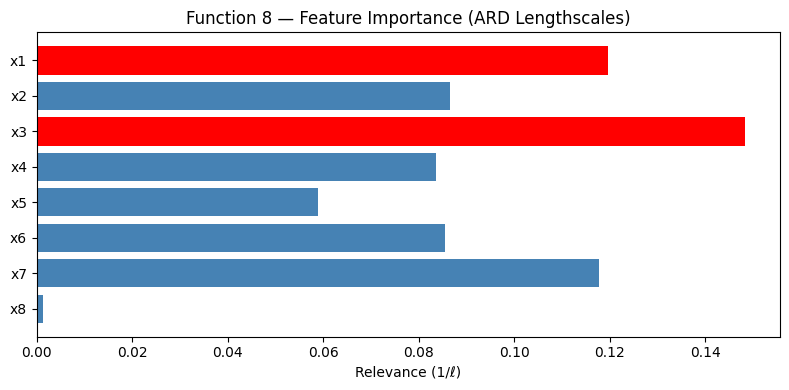

Top-2 most relevant dimensions (red):
  x3: ℓ=6.7453, 1/ℓ=0.1483
  x1: ℓ=8.3578, 1/ℓ=0.1196


In [6]:
# Feature importance: inverse lengthscale (1/ℓ)
importance = 1.0 / lengthscales
sorted_idx = np.argsort(importance)[::-1]  # descending
top2 = set(sorted_idx[:2])

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['red' if i in top2 else 'steelblue' for i in range(DIM)]
dim_labels = [f'x{i+1}' for i in range(DIM)]

ax.barh(dim_labels, importance, color=colors)
ax.set_xlabel('Relevance (1/ℓ)')
ax.set_title('Function 8 — Feature Importance (ARD Lengthscales)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top-2 most relevant dimensions (red):")
for idx in sorted_idx[:2]:
    print(f"  x{idx+1}: ℓ={lengthscales[idx]:.4f}, 1/ℓ={importance[idx]:.4f}")

### Step 5: Visualise SFGP Surrogate

Three-panel 2D slice through the top-2 most relevant dimensions (by shortest ARD lengthscale), with all other dimensions fixed at the best observed point.
- **(a) GP Posterior Mean** (viridis)
- **(b) GP Posterior Std** (magma)
- **(c) Analytic EI** (plasma) — using `ExpectedImprovement` for computational speed

White star = best observed. Red X = proposed candidate.

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/botorch/acquisition/analytic.py:340: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


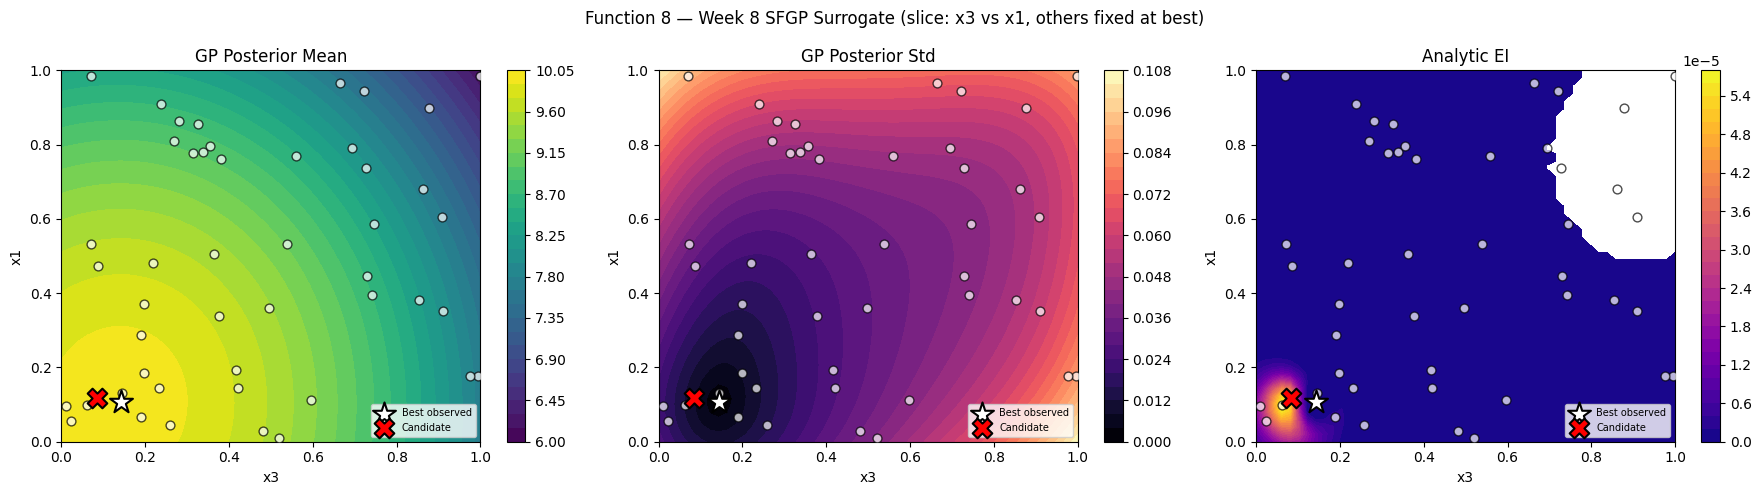

In [7]:
# ── Identify top-2 dimensions and best observed point ─────────────────────────
dim_a, dim_b = sorted_idx[0], sorted_idx[1]  # shortest lengthscales
best_idx = y_w8.argmax()
best_point = X_w8[best_idx]

# ── Build 50×50 grid over top-2 dims, fix others at best observed ─────────────
n_grid = 50
xa_lin = np.linspace(0, 1, n_grid)
xb_lin = np.linspace(0, 1, n_grid)
XA, XB = np.meshgrid(xa_lin, xb_lin)

# Create full 8D grid with fixed dimensions
grid_np = np.tile(best_point, (n_grid * n_grid, 1))
grid_np[:, dim_a] = XA.ravel()
grid_np[:, dim_b] = XB.ravel()
grid_t = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid ─────────────────────────────────────────
model.eval()
with torch.no_grad():
    posterior = model.posterior(grid_t)
    mean_grid = posterior.mean.numpy().reshape(n_grid, n_grid)
    std_grid = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# ── Analytic EI on grid (faster than MC-based qEI for visualisation) ──────────
ei_analytic = ExpectedImprovement(model=model, best_f=best_f)
ei_vals = []
batch_size = 500
for i in range(0, len(grid_np), batch_size):
    batch = grid_t[i:i + batch_size]
    with torch.no_grad():
        ei_vals.append(ei_analytic(batch.unsqueeze(1)).numpy())
ei_grid = np.concatenate(ei_vals).reshape(n_grid, n_grid)

# ── Extract candidate coords in top-2 dims ───────────────────────────────────
cand_a = max(0.0, min(1.0, next_x[dim_a].item()))
cand_b = max(0.0, min(1.0, next_x[dim_b].item()))

# ── Three-panel figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, cmap, title in zip(
    axes, [mean_grid, std_grid, ei_grid],
    ['viridis', 'magma', 'plasma'],
    ['GP Posterior Mean', 'GP Posterior Std', 'Analytic EI']
):
    c = ax.contourf(XA, XB, data, levels=30, cmap=cmap)
    ax.scatter(X_w8[:, dim_a], X_w8[:, dim_b], c='white', edgecolors='black', s=40, zorder=5, alpha=0.7)
    ax.scatter(best_point[dim_a], best_point[dim_b], c='white', marker='*', s=300, edgecolors='black', linewidths=1.5, zorder=6, label='Best observed')
    ax.scatter(cand_a, cand_b, c='red', marker='X', s=200, edgecolors='black', linewidths=1.5, zorder=6, label='Candidate')
    ax.set_xlabel(f'x{dim_a+1}'); ax.set_ylabel(f'x{dim_b+1}')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=7)
    plt.colorbar(c, ax=ax)

plt.suptitle(f'Function 8 — Week 8 SFGP Surrogate (slice: x{dim_a+1} vs x{dim_b+1}, others fixed at best)', fontsize=12)
plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum across all 48 observations. Weekly boundaries show when each batch of data was collected.

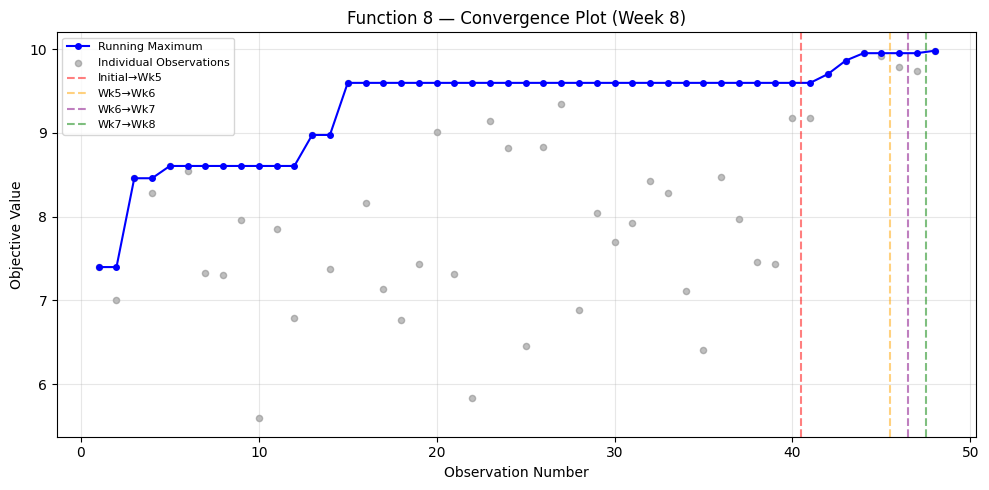

Best observed value: 9.982473
Achieved at observation: 48
Week 8 observation improved best: Yes ✓


In [8]:
# Running maximum (convergence) over all 48 observations
running_max = np.maximum.accumulate(y_w8)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w8) + 1), running_max, 'b-o', markersize=4, label='Running Maximum')
plt.scatter(range(1, len(y_w8) + 1), y_w8, c='gray', alpha=0.5, s=20, label='Individual Observations')

# Weekly boundaries
boundaries = {40.5: 'Initial→Wk5', 45.5: 'Wk5→Wk6', 46.5: 'Wk6→Wk7', 47.5: 'Wk7→Wk8'}
colors_bd = ['red', 'orange', 'purple', 'green']
for (bx, blabel), bc in zip(boundaries.items(), colors_bd):
    plt.axvline(x=bx, color=bc, linestyle='--', alpha=0.5, label=blabel)

plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 8 — Convergence Plot (Week 8)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w8.max():.6f}")
print(f"Achieved at observation: {y_w8.argmax() + 1}")
improved = y_w8[-1] > np.max(y_w8[:-1])
print(f"Week 8 observation improved best: {'Yes ✓' if improved else 'No — previous best retained'}")

### Step 7: Format Submission Query

Format the proposed next sample point as an 8-component string with 6 decimal places, clamped to `[0.0, 0.999999]`.

In [9]:
# Helper function for formatting submission queries
def format_query(point, dim):
    """Clamp each coordinate to [0, 0.999999] and format as submission string."""
    coords = [max(0.0, min(0.999999, point[i].item() if torch.is_tensor(point) else point[i])) for i in range(dim)]
    return "-".join(f"{c:.6f}" for c in coords)

# Format submission
proposed_query = format_query(next_x, DIM)

# Verify no duplicate with existing observations
observed_queries = [format_query(X_w8[i], DIM) for i in range(len(X_w8))]
is_duplicate = proposed_query in observed_queries

print("=" * 80)
print("WEEK 8 SUBMISSION QUERY FOR FUNCTION 8")
print("=" * 80)
print(f"Surrogate:    SFGP (Matérn-2.5, ARD={DIM}d, noise_lb=1e-7, Standardize)")
print(f"Acquisition:  qExpectedImprovement (qEI, XI={XI}, MC={MC_SAMPLES})")
print(f"Fallback:     {'ACTIVATED — Sobol posterior mean' if used_fallback else 'Not needed'}")
print(f"Best observed y: {y_w8.max():.6f}")
print(f"Duplicate check: {'⚠ DUPLICATE' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 80)

WEEK 8 SUBMISSION QUERY FOR FUNCTION 8
Surrogate:    SFGP (Matérn-2.5, ARD=8d, noise_lb=1e-7, Standardize)
Acquisition:  qExpectedImprovement (qEI, XI=0.01, MC=256)
Fallback:     ACTIVATED — Sobol posterior mean
Best observed y: 9.982473
Duplicate check: OK — unique point

>>> SUBMISSION: 0.117084-0.041402-0.084333-0.297372-0.826500-0.565729-0.051564-0.482499
